Форма: (2626, 1)
Начало: 2017-01-01 00:00:00
Конец: 2017-04-20 09:00:00

Пропуски:
Users    1
dtype: int64

Описательные статистики:
               Users
count    2625.000000
mean    40483.884190
std     14304.659157
min         0.000000
25%     29346.000000
50%     38314.000000
75%     48996.000000
max    110716.000000


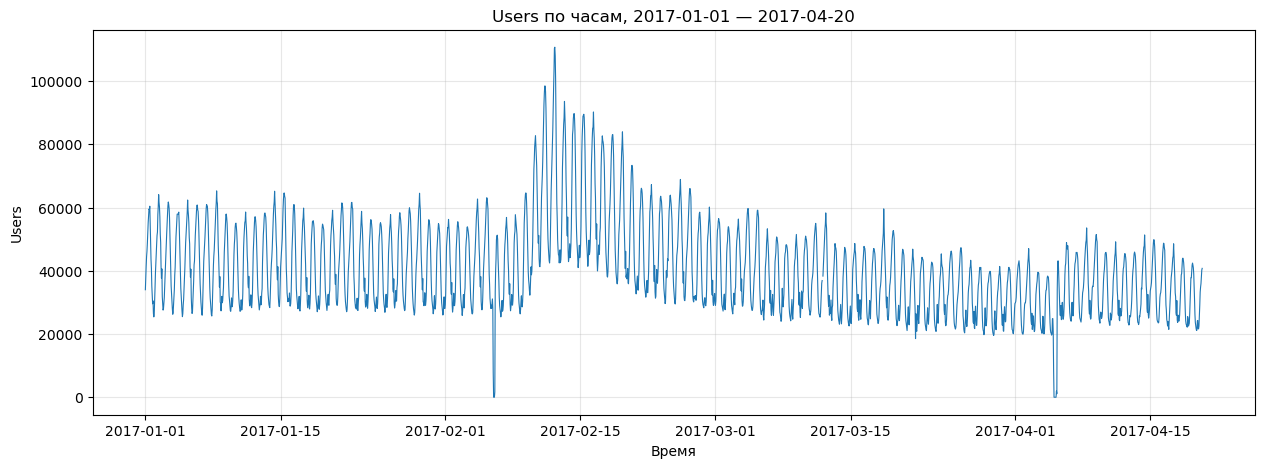

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Загрузка
df = pd.read_csv('TS (1) (1).csv')

# 2. Парсинг времени
df['Time'] = pd.to_datetime(df['Time'], format='%m/%d/%y %H:%M')

# 3. Индекс и сортировка
df = df.set_index('Time').sort_index()

# 4. Регулярная частота — час
df = df.asfreq('h')

# 5. Базовая информация
print('Форма:', df.shape)
print('Начало:', df.index.min())
print('Конец:', df.index.max())
print('\nПропуски:')
print(df.isna().sum())
print('\nОписательные статистики:')
print(df.describe())

# 6. График всего ряда
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Users'], linewidth=0.8)
plt.title('Users по часам, 2017-01-01 — 2017-04-20')
plt.xlabel('Время')
plt.ylabel('Users')
plt.grid(alpha=0.3)
plt.show()

In [2]:
# Провал 1: 2017-02-06 00:00 – 2017-02-06 04:00
print(df.loc['2017-02-05 22:00':'2017-02-06 08:00'])

# Провал 2: 2017-04-05 00:00 – 2017-04-05 08:00
print(df.loc['2017-04-04 22:00':'2017-04-05 10:00'])

df_clean = df.copy()
mask = df_clean['Users'] < 10000
print('Аномальных точек:', mask.sum())
print(df_clean[mask])

df_clean.loc[mask, 'Users'] = np.nan
df_clean['Users'] = df_clean['Users'].interpolate(method='time')

print('\nПропусков после чистки:', df_clean['Users'].isna().sum())

                       Users
Time                        
2017-02-05 22:00:00  31097.0
2017-02-05 23:00:00  28245.0
2017-02-06 00:00:00   7930.0
2017-02-06 01:00:00      0.0
2017-02-06 02:00:00      0.0
2017-02-06 03:00:00      0.0
2017-02-06 04:00:00   1680.0
2017-02-06 05:00:00  33339.0
2017-02-06 06:00:00  40040.0
2017-02-06 07:00:00  43712.0
2017-02-06 08:00:00  49772.0
                       Users
Time                        
2017-04-04 22:00:00  24870.0
2017-04-04 23:00:00  20743.0
2017-04-05 00:00:00   8177.0
2017-04-05 01:00:00      0.0
2017-04-05 02:00:00      0.0
2017-04-05 03:00:00      0.0
2017-04-05 04:00:00      0.0
2017-04-05 05:00:00      0.0
2017-04-05 06:00:00      0.0
2017-04-05 07:00:00   1931.0
2017-04-05 08:00:00   1111.0
2017-04-05 09:00:00  34142.0
2017-04-05 10:00:00  42048.0
Аномальных точек: 14
                      Users
Time                       
2017-02-06 00:00:00  7930.0
2017-02-06 01:00:00     0.0
2017-02-06 02:00:00     0.0
2017-02-06 03:00:00     0.0

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15288\1346828569.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(w) + pd.Timedelta(days=7)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15288\1346828569.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(w) + pd.Timedelta(days=7)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15288\1346828569.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  end = pd.Timestamp(w) + pd.Timedelta(days=7)
C:\Users\ASUS\AppData\

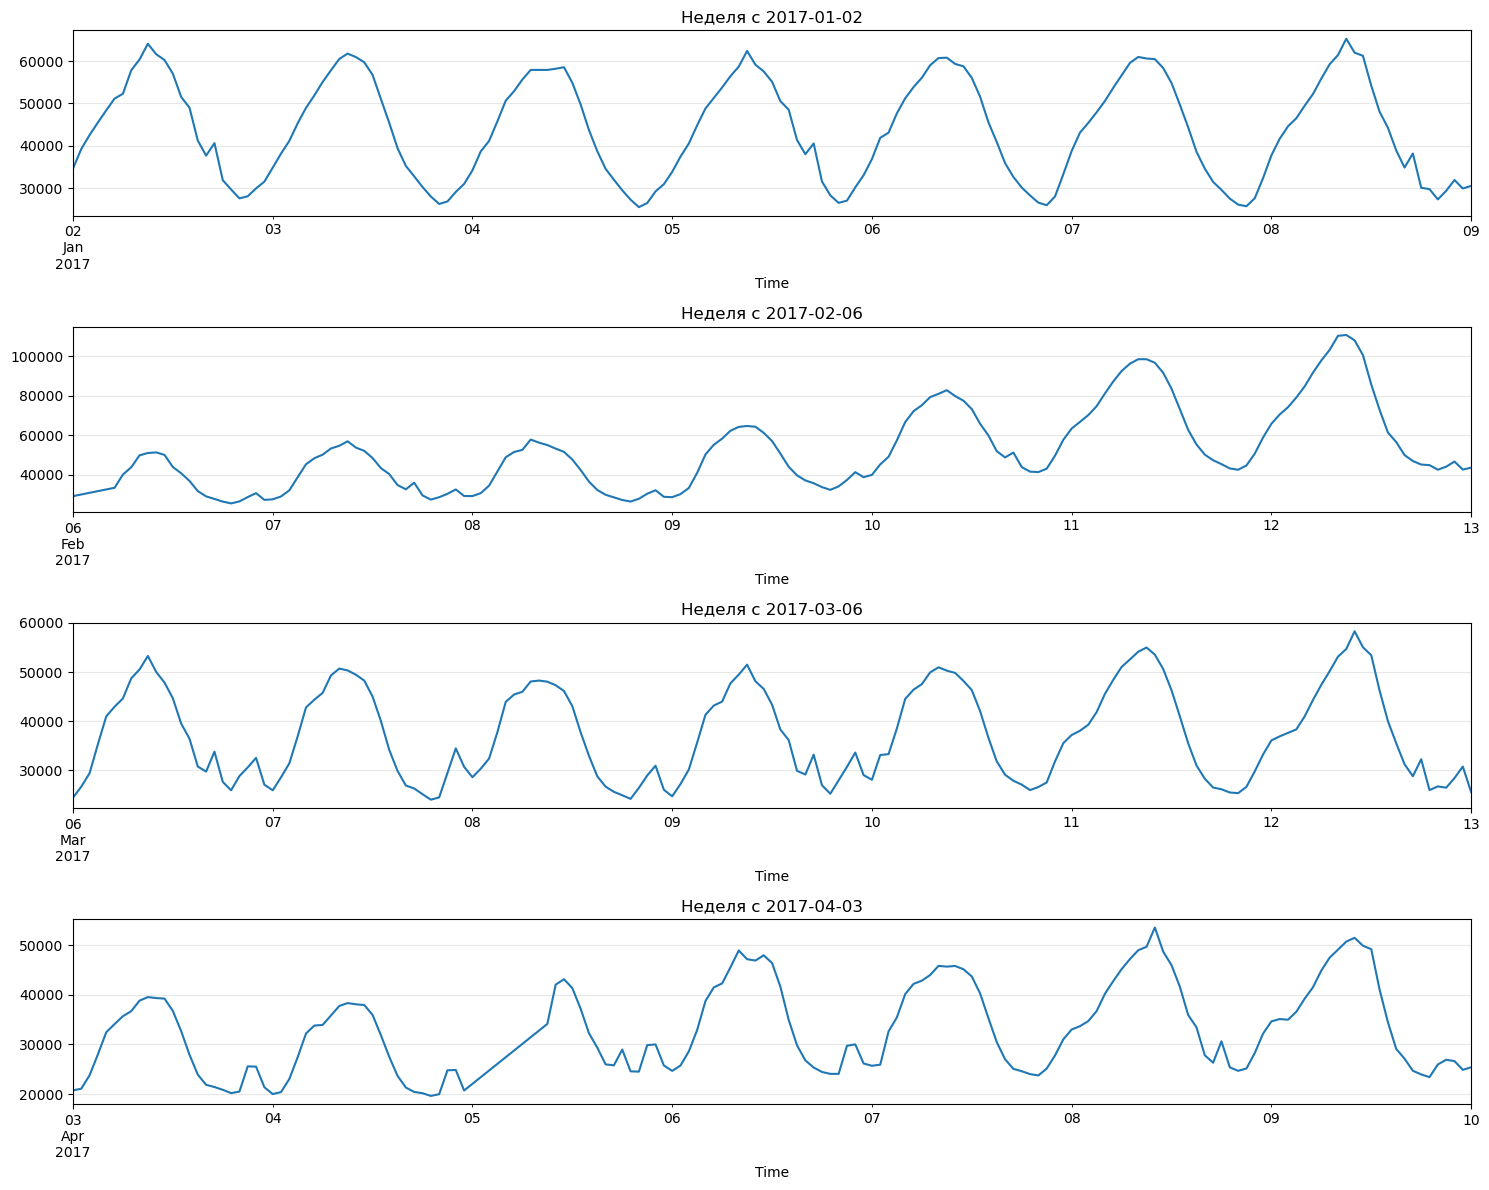

              mean           std   median
Time                                     
0     31878.599091   8317.214081  29077.0
1     33698.307273   9286.803080  30479.5
2     36312.160909   9386.168398  33426.0
3     40789.687273  10114.245996  39952.5
4     45948.686364  11296.099387  45937.5
5     49036.403636  12158.335051  48890.0
6     51309.320909  12815.929967  50887.0
7     54106.465455  13331.308406  53670.0
8     55803.028182  13281.529296  54930.5
9     56771.663636  13462.343487  55359.5
10    56041.577982  12400.784689  53899.0
11    54189.275229  11522.300714  52173.0
12    50527.990826   9839.300748  49013.0
13    45088.541284   8353.116836  43283.0
14    39786.449541   7691.705650  38424.0
15    34816.000000   6864.060657  33723.0
16    31537.192661   6605.891368  30674.0
17    30982.642202   7722.994645  29450.0
18    29058.623853   5642.156803  28818.0
19    27349.045872   5361.732104  27048.0
20    27474.137615   5412.597007  27184.0
21    29336.100917   5504.072871  

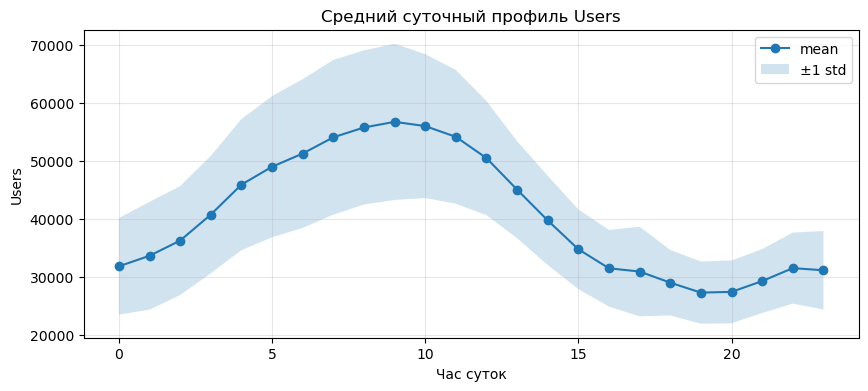

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=False)
weeks = ['2017-01-02', '2017-02-06', '2017-03-06', '2017-04-03']

for ax, w in zip(axes, weeks):
    end = pd.Timestamp(w) + pd.Timedelta(days=7)
    df_clean.loc[w:end, 'Users'].plot(ax=ax, title=f'Неделя с {w}')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

profile = df_clean.groupby(df_clean.index.hour)['Users'].agg(['mean', 'std', 'median'])
print(profile)

plt.figure(figsize=(10, 4))
plt.plot(profile.index, profile['mean'], marker='o', label='mean')
plt.fill_between(profile.index,
                 profile['mean'] - profile['std'],
                 profile['mean'] + profile['std'],
                 alpha=0.2, label='±1 std')
plt.title('Средний суточный профиль Users')
plt.xlabel('Час суток')
plt.ylabel('Users')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

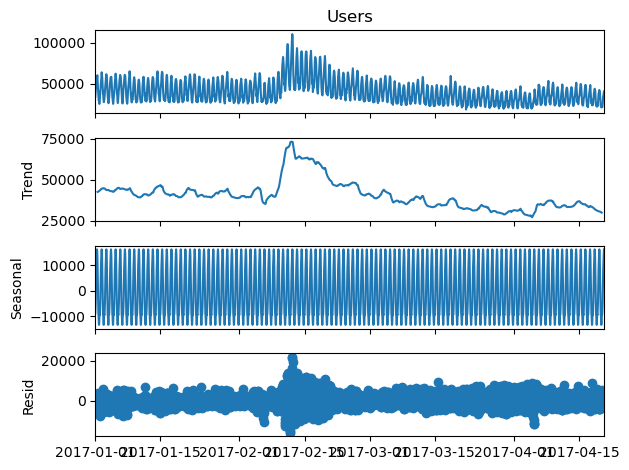

Time
0    39106.054688
1    38632.828125
2    38742.485677
3    39519.035135
4    41505.152778
5    43717.708333
6    43377.093750
Name: Users, dtype: float64


In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_clean['Users'], model='additive', period=24)
decomp.plot()
plt.show()

dow = df_clean.groupby(df_clean.index.dayofweek)['Users'].mean()
print(dow)

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    s = series.dropna()
    result = adfuller(s, autolag='AIC')
    print(f'{name}:')
    print(f'  ADF статистика = {result[0]:.4f}')
    print(f'  p-value        = {result[1]:.4f}')
    print(f'  Крит. значения: {result[4]}')
    print()

series = df_clean['Users']

adf_report(series, 'Сырой ряд')
adf_report(series.diff(1), 'Первая разность (d=1)')
adf_report(series.diff(24), 'Сезонная разность (D=1, m=24)')
adf_report(series.diff(1).diff(24), 'Обе разности (d=1, D=1)')

Сырой ряд:
  ADF статистика = -2.0407
  p-value        = 0.2690
  Крит. значения: {'1%': np.float64(-3.4328705142046463), '5%': np.float64(-2.862653568070648), '10%': np.float64(-2.5673627923113798)}

Первая разность (d=1):
  ADF статистика = -9.3575
  p-value        = 0.0000
  Крит. значения: {'1%': np.float64(-3.4328714860895135), '5%': np.float64(-2.862653997269672), '10%': np.float64(-2.567363020820226)}

Сезонная разность (D=1, m=24):
  ADF статистика = -6.4923
  p-value        = 0.0000
  Крит. значения: {'1%': np.float64(-3.4328940481540635), '5%': np.float64(-2.862663960978616), '10%': np.float64(-2.5673683255817044)}

Обе разности (d=1, D=1):
  ADF статистика = -14.5536
  p-value        = 0.0000
  Крит. значения: {'1%': np.float64(-3.4328940481540635), '5%': np.float64(-2.862663960978616), '10%': np.float64(-2.5673683255817044)}



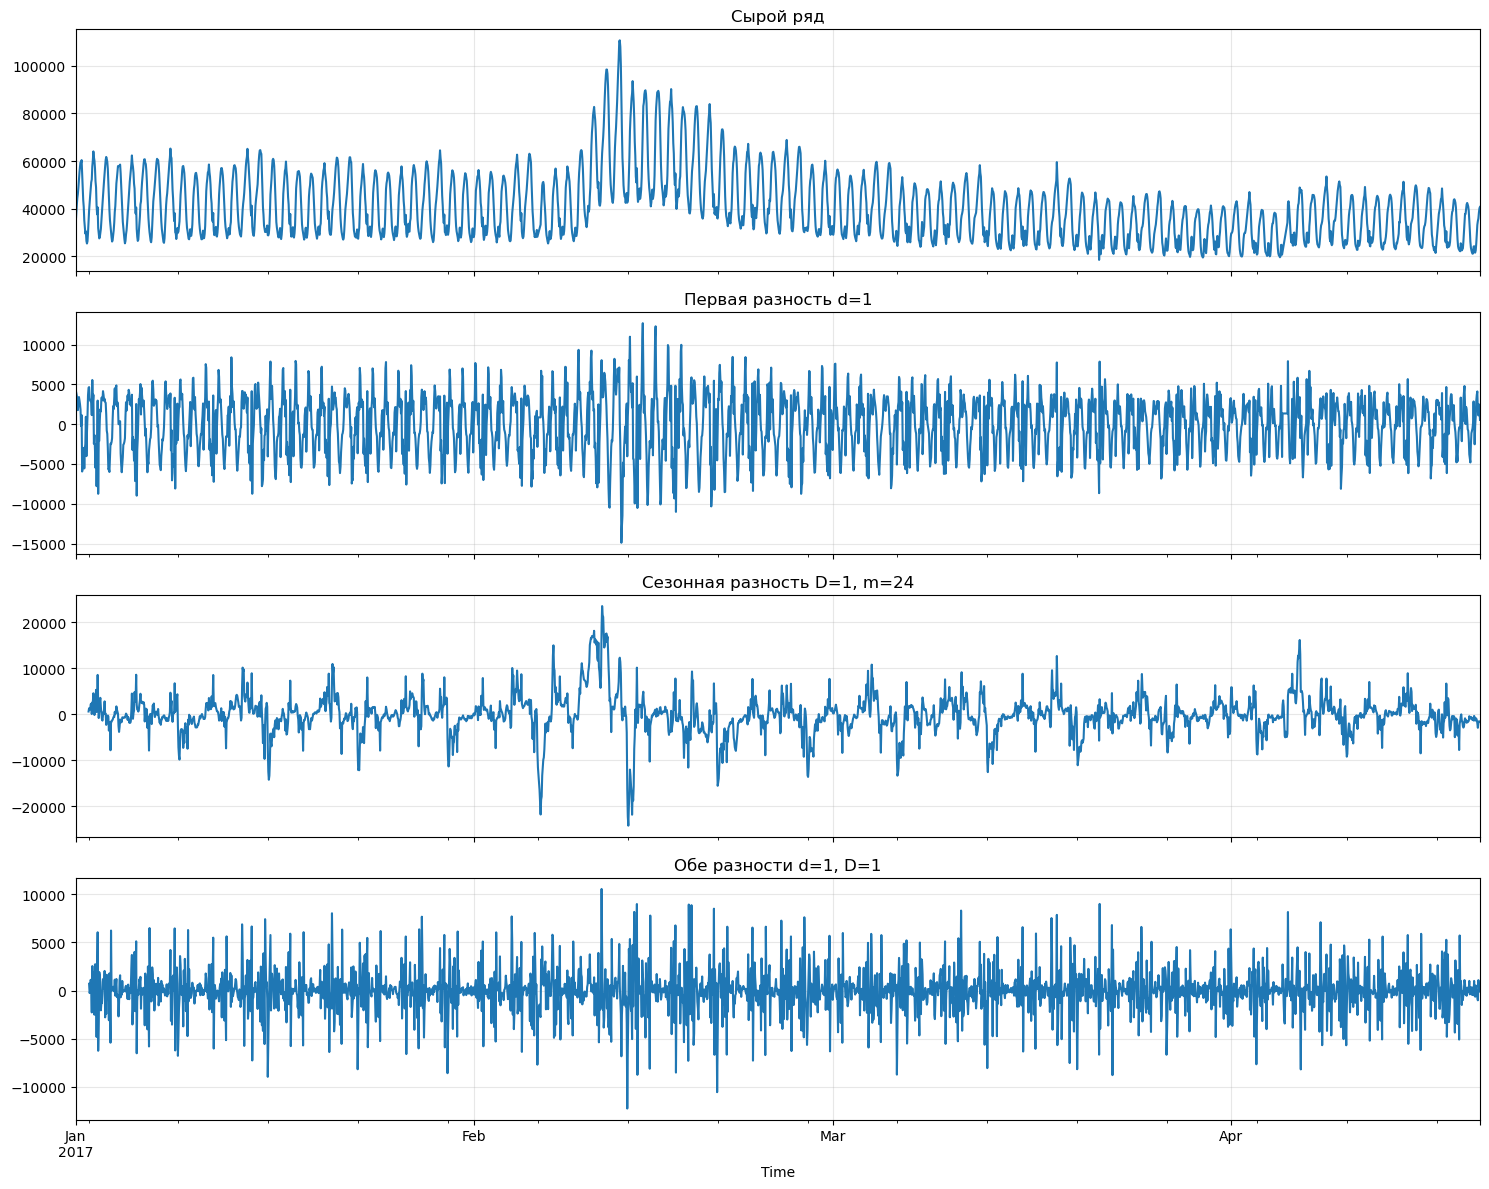

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

series.plot(ax=axes[0], title='Сырой ряд')
series.diff(1).plot(ax=axes[1], title='Первая разность d=1')
series.diff(24).plot(ax=axes[2], title='Сезонная разность D=1, m=24')
series.diff(1).diff(24).plot(ax=axes[3], title='Обе разности d=1, D=1')

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

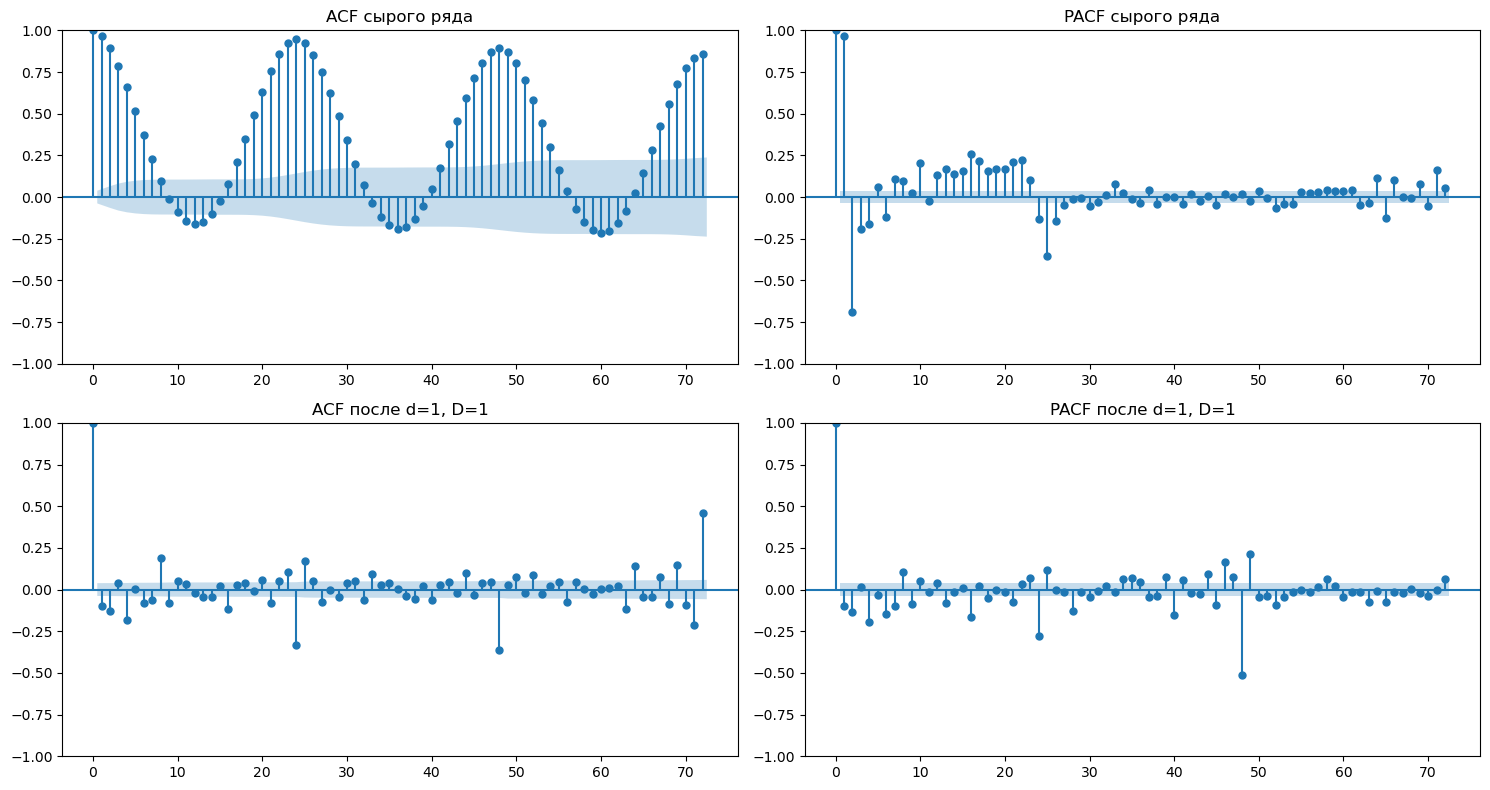

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

s = series.diff(1).diff(24).dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

plot_acf(series.dropna(), lags=72, ax=axes[0, 0], title='ACF сырого ряда')
plot_pacf(series.dropna(), lags=72, ax=axes[0, 1], title='PACF сырого ряда')
plot_acf(s, lags=72, ax=axes[1, 0], title='ACF после d=1, D=1')
plot_pacf(s, lags=72, ax=axes[1, 1], title='PACF после d=1, D=1')

plt.tight_layout()
plt.show()

Train: 2017-01-01 00:00:00 — 2017-03-31 23:00:00 | len = 2160
Test : 2017-04-01 00:00:00 — 2017-04-20 09:00:00 | len = 466


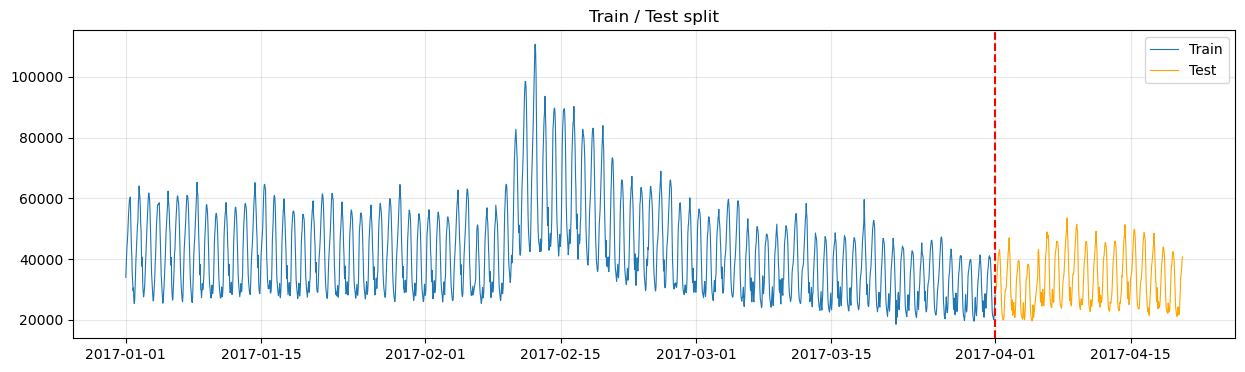

In [8]:
series = df_clean['Users']

train = series.loc[:'2017-03-31 23:00']
test  = series.loc['2017-04-01 00:00':]

print('Train:', train.index.min(), '—', train.index.max(), '| len =', len(train))
print('Test :', test.index.min(),  '—', test.index.max(),  '| len =', len(test))

# Визуально убедимся в границе
plt.figure(figsize=(15, 4))
plt.plot(train.index, train, label='Train', linewidth=0.8)
plt.plot(test.index, test, label='Test', color='orange', linewidth=0.8)
plt.axvline(pd.Timestamp('2017-04-01'), color='red', linestyle='--')
plt.title('Train / Test split')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (1, 1, 1)
seasonal_order = (1, 1, 1, 24)

model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

res = model.fit(disp=False)
print(res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Users   No. Observations:                 2160
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood              -18858.625
Date:                            Mon, 05 Oct 2026   AIC                          37727.250
Time:                                    16:16:26   BIC                          37755.520
Sample:                                01-01-2017   HQIC                         37737.602
                                     - 03-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8629      0.015     56.603      0.000       0.833       0.893
ma.L1         -0.9535      0.009   

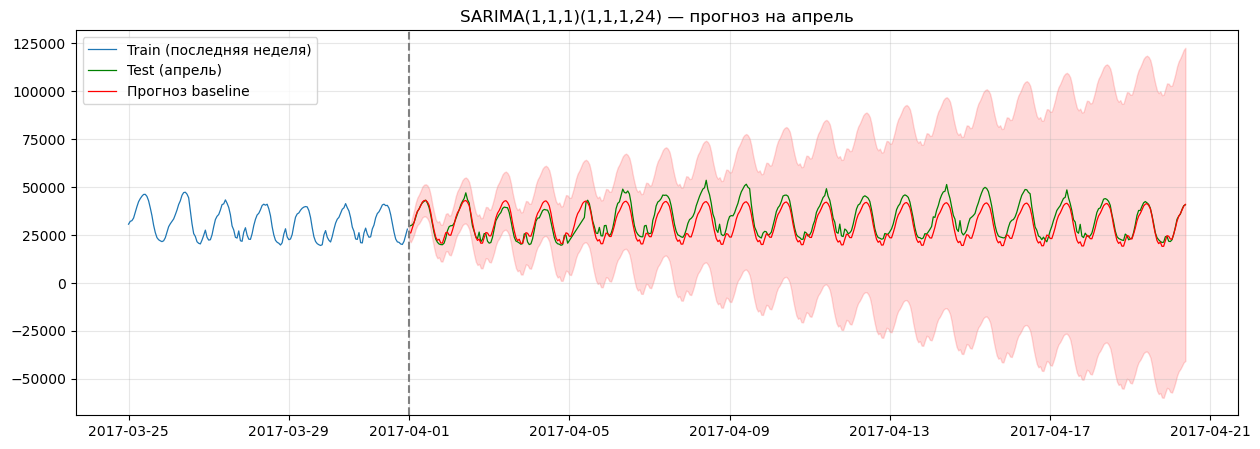

In [10]:
forecast = res.get_forecast(steps=len(test))
pred = forecast.predicted_mean
ci = forecast.conf_int()

plt.figure(figsize=(15, 5))
plt.plot(train.index[-168:], train.iloc[-168:], label='Train (последняя неделя)', linewidth=0.9)
plt.plot(test.index, test, label='Test (апрель)', color='green', linewidth=0.9)
plt.plot(pred.index, pred, label='Прогноз baseline', color='red', linewidth=0.9)
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color='red', alpha=0.15)
plt.axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--')
plt.legend()
plt.title('SARIMA(1,1,1)(1,1,1,24) — прогноз на апрель')
plt.grid(alpha=0.3)
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def metrics(y_true, y_pred, name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name}: MAE = {mae:,.0f} | RMSE = {rmse:,.0f} | MAPE = {mape:.2f}%')
    return mae, rmse, mape

metrics(test, pred, 'Baseline (1,1,1)(1,1,1,24)')

Baseline (1,1,1)(1,1,1,24): MAE = 3,701 | RMSE = 4,412 | MAPE = 11.13%


(3701.1650175534633,
 np.float64(4411.795603923052),
 np.float64(11.133230104015434))

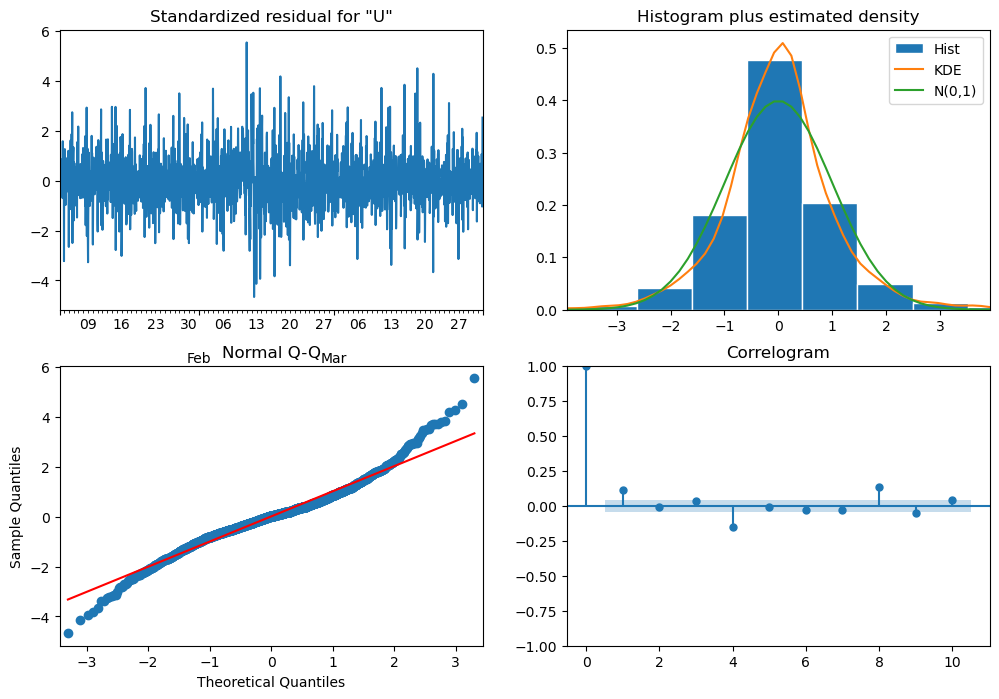

       lb_stat     lb_pvalue
1     7.867494  5.033137e-03
6    43.701367  8.471649e-08
12   90.043254  4.843098e-14
24  203.545333  2.150750e-30
48  435.268919  7.692087e-64
72  676.370267  4.803087e-99


In [12]:
res.plot_diagnostics(figsize=(12, 8))
plt.show()

from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(res.resid, lags=[1, 6, 12, 24, 48, 72], return_df=True)
print(lb)

In [13]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

results_grid = []
p_range = [0, 1, 2]
q_range = [0, 1, 2]
P_range = [0, 1]
Q_range = [0, 1]

for p, q, P, Q in itertools.product(p_range, q_range, P_range, Q_range):
    order = (p, 1, q)
    seasonal_order = (P, 1, Q, 24)
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        res = model.fit(disp=False)
        results_grid.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': res.aic,
            'BIC': res.bic,
            'HQIC': res.hqic,
            'LLF': res.llf,
        })
        print(f'{order} x {seasonal_order} | AIC={res.aic:.1f} BIC={res.bic:.1f}')
    except Exception as e:
        print(f'{order} x {seasonal_order} | FAIL: {e}')

grid_df = pd.DataFrame(results_grid).sort_values('AIC').reset_index(drop=True)
print('\nТоп-10 по AIC:')
print(grid_df.head(10))
print('\nТоп-10 по BIC:')
print(grid_df.sort_values("BIC").head(10))

(0, 1, 0) x (0, 1, 0, 24) | AIC=39099.8 BIC=39105.4
(0, 1, 0) x (0, 1, 1, 24) | AIC=37840.5 BIC=37851.8
(0, 1, 0) x (1, 1, 0, 24) | AIC=38427.9 BIC=38439.2
(0, 1, 0) x (1, 1, 1, 24) | AIC=37899.9 BIC=37916.9
(0, 1, 1) x (0, 1, 0, 24) | AIC=39055.9 BIC=39067.3
(0, 1, 1) x (0, 1, 1, 24) | AIC=37793.3 BIC=37810.3
(0, 1, 1) x (1, 1, 0, 24) | AIC=38441.5 BIC=38458.4
(0, 1, 1) x (1, 1, 1, 24) | AIC=37777.5 BIC=37800.1
(0, 1, 2) x (0, 1, 0, 24) | AIC=38989.7 BIC=39006.7
(0, 1, 2) x (0, 1, 1, 24) | AIC=37911.3 BIC=37933.9
(0, 1, 2) x (1, 1, 0, 24) | AIC=38401.8 BIC=38424.4
(0, 1, 2) x (1, 1, 1, 24) | AIC=37749.0 BIC=37777.2
(1, 1, 0) x (0, 1, 0, 24) | AIC=39080.1 BIC=39091.4
(1, 1, 0) x (0, 1, 1, 24) | AIC=37813.3 BIC=37830.3
(1, 1, 0) x (1, 1, 0, 24) | AIC=38424.1 BIC=38441.1
(1, 1, 0) x (1, 1, 1, 24) | AIC=37795.4 BIC=37818.0
(1, 1, 1) x (0, 1, 0, 24) | AIC=38970.9 BIC=38987.9
(1, 1, 1) x (0, 1, 1, 24) | AIC=37765.5 BIC=37788.1
(1, 1, 1) x (1, 1, 0, 24) | AIC=38333.6 BIC=38356.2
(1, 1, 1) x 

In [14]:
best = grid_df.iloc[0]
print('Лучшая модель:', best['order'], 'x', best['seasonal_order'])

final_model = SARIMAX(
    train,
    order=best['order'],
    seasonal_order=best['seasonal_order'],
    enforce_stationarity=False,
    enforce_invertibility=False,
)
final_res = final_model.fit(disp=False)
print(final_res.summary())

Лучшая модель: (2, 1, 2) x (1, 1, 1, 24)
                                      SARIMAX Results                                       
Dep. Variable:                                Users   No. Observations:                 2160
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood              -18823.159
Date:                              Mon, 05 Oct 2026   AIC                          37660.318
Time:                                      16:32:53   BIC                          37699.892
Sample:                                  01-01-2017   HQIC                         37674.810
                                       - 03-31-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3733      0.069      5.427      0.000   

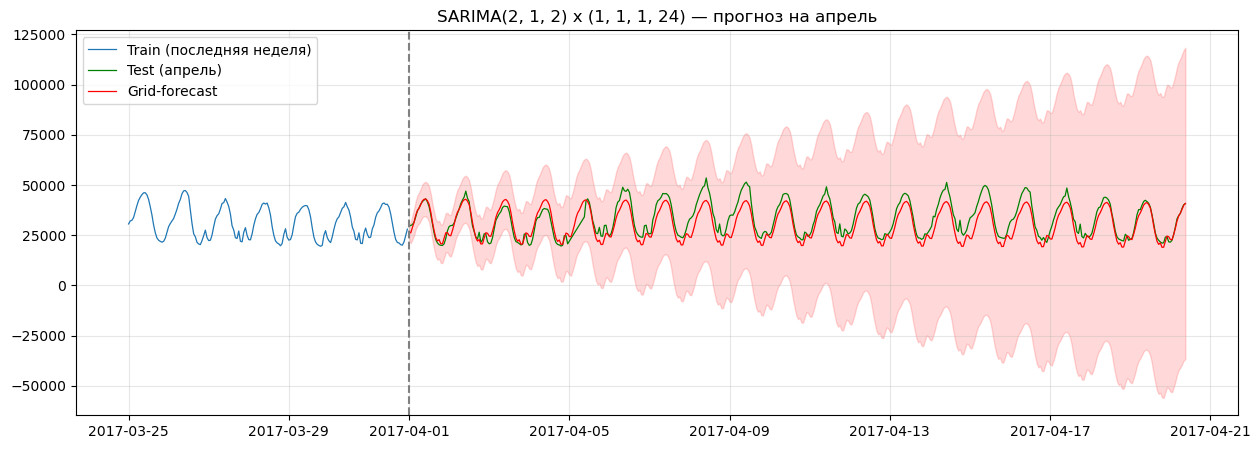

Grid-best: MAE = 3,738 | RMSE = 4,451 | MAPE = 11.24%


(3738.2953884475155,
 np.float64(4450.663265771431),
 np.float64(11.23501423632112))

In [15]:
forecast = final_res.get_forecast(steps=len(test))
pred_grid = forecast.predicted_mean
ci_grid = forecast.conf_int()

plt.figure(figsize=(15, 5))
plt.plot(train.index[-168:], train.iloc[-168:], label='Train (последняя неделя)', linewidth=0.9)
plt.plot(test.index, test, label='Test (апрель)', color='green', linewidth=0.9)
plt.plot(pred_grid.index, pred_grid, label='Grid-forecast', color='red', linewidth=0.9)
plt.fill_between(ci_grid.index, ci_grid.iloc[:, 0], ci_grid.iloc[:, 1], color='red', alpha=0.15)
plt.axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--')
plt.legend()
plt.title(f'SARIMA{best["order"]} x {best["seasonal_order"]} — прогноз на апрель')
plt.grid(alpha=0.3)
plt.show()

metrics(test, pred_grid, 'Grid-best')

In [16]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

train_log = np.log1p(train)
model_log = SARIMAX(
    train_log,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res_log = model_log.fit(disp=False)
print(res_log.summary())

fc_log = res_log.get_forecast(steps=len(test))
pred_log = fc_log.predicted_mean
# Среднее в лог-шкале -> expm1 даёт медиану. Для MAPE обычно ок,
# но можно ещё добавить поправку на дисперсию: exp(mu + sigma^2/2)
pred_log_inv = np.expm1(pred_log)

metrics(test, pred_log_inv, 'SARIMA (2,1,2) на log1p')

                                      SARIMAX Results                                       
Dep. Variable:                                Users   No. Observations:                 2160
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood                3418.095
Date:                              Mon, 05 Oct 2026   AIC                          -6822.189
Time:                                      16:33:50   BIC                          -6782.615
Sample:                                  01-01-2017   HQIC                         -6807.697
                                       - 03-31-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2590      0.074      3.513      0.000       0.115       0.404
ar.L2          0.28

(4688.908605003257,
 np.float64(5460.195468340034),
 np.float64(13.792178387759826))

In [17]:
def fourier_terms(index, period, K):
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f'sin_{period}_{k}'] = np.sin(2 * np.pi * k * t / period)
        cols[f'cos_{period}_{k}'] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

X_all = pd.concat([
    fourier_terms(series.index, period=24, K=3),
    fourier_terms(series.index, period=24*7, K=2),
], axis=1)

X_train = X_all.loc[train.index]
X_test  = X_all.loc[test.index]

model_x = SARIMAX(
    train,
    exog=X_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res_x = model_x.fit(disp=False)
print(res_x.summary())

fc_x = res_x.get_forecast(steps=len(test), exog=X_test)
pred_x = fc_x.predicted_mean

metrics(test, pred_x, 'SARIMA (2,1,2) + Fourier(24,168)')

                                      SARIMAX Results                                       
Dep. Variable:                                Users   No. Observations:                 2160
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 24)   Log Likelihood         -1512549678.440
Date:                              Mon, 05 Oct 2026   AIC                     3025099390.879
Time:                                      16:38:13   BIC                     3025099486.988
Sample:                                  01-01-2017   HQIC                    3025099426.075
                                       - 03-31-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_24_1   -2.685e+14        nan        nan        nan         nan         nan
cos_24_1   -4.003e+

(12446.816708020386,
 np.float64(14996.979616804487),
 np.float64(40.07925369841946))

In [18]:
t_train = np.arange(len(train)).reshape(-1, 1)
t_test  = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

model_t = SARIMAX(
    train,
    exog=t_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res_t = model_t.fit(disp=False)
pred_t = res_t.get_forecast(steps=len(test), exog=t_test).predicted_mean

metrics(test, pred_t, 'SARIMA (2,1,2) + linear trend')

SARIMA (2,1,2) + linear trend: MAE = 3,658 | RMSE = 4,370 | MAPE = 10.99%


(3657.5794530277058,
 np.float64(4370.410157410313),
 np.float64(10.991954744033405))

In [19]:
results = {}
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    results[name] = dict(MAE=mae, RMSE=rmse, MAPE=mape)
    print(f'{name:<38} MAE={mae:>7,.0f}  RMSE={rmse:>7,.0f}  MAPE={mape:>6.2f}%')

evaluate('baseline (1,1,1)(1,1,1,24)',      test, pred)
evaluate('grid-best (2,1,2)(1,1,1,24)',     test, pred_grid)
evaluate('log1p (2,1,2)(1,1,1,24)',         test, pred_log_inv)
evaluate('Fourier + (2,1,2)(1,1,1,24)',     test, pred_x)
evaluate('trend + (2,1,2)(1,1,1,24)',       test, pred_t)

pd.DataFrame(results).T

baseline (1,1,1)(1,1,1,24)             MAE=  3,701  RMSE=  4,412  MAPE= 11.13%
grid-best (2,1,2)(1,1,1,24)            MAE=  3,738  RMSE=  4,451  MAPE= 11.24%
log1p (2,1,2)(1,1,1,24)                MAE=  4,689  RMSE=  5,460  MAPE= 13.79%
Fourier + (2,1,2)(1,1,1,24)            MAE= 12,447  RMSE= 14,997  MAPE= 40.08%
trend + (2,1,2)(1,1,1,24)              MAE=  3,658  RMSE=  4,370  MAPE= 10.99%


,MAE,RMSE,MAPE
"baseline (1,1,1)(1,1,1,24)",3701.165018,4411.795604,11.133230
"grid-best (2,1,2)(1,1,1,24)",3738.295388,4450.663266,11.235014
"log1p (2,1,2)(1,1,1,24)",4688.908605,5460.195468,13.792178
"Fourier + (2,1,2)(1,1,1,24)",12446.816708,14996.979617,40.079254
"trend + (2,1,2)(1,1,1,24)",3657.579453,4370.410157,10.991955


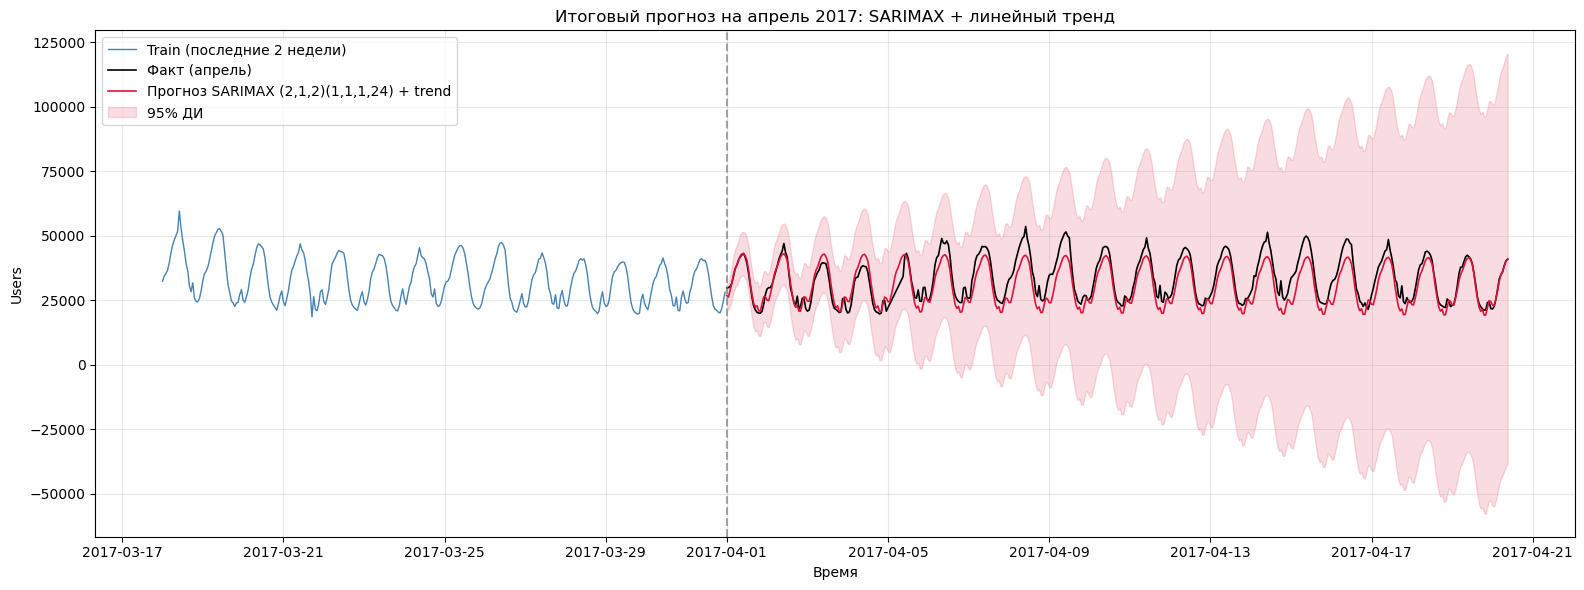

FINAL: trend + (2,1,2)(1,1,1,24): MAE = 3,658 | RMSE = 4,370 | MAPE = 10.99%


(3657.5794530277058,
 np.float64(4370.410157410313),
 np.float64(10.991954744033405))

In [20]:
# Финальная модель
model_final = SARIMAX(
    train,
    exog=t_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
res_final = model_final.fit(disp=False)

fc_final = res_final.get_forecast(steps=len(test), exog=t_test)
pred_final = fc_final.predicted_mean
ci_final   = fc_final.conf_int()

# Финальный график: train-хвост + test + прогноз + ДИ
plt.figure(figsize=(16, 6))
plt.plot(train.index[-336:], train.iloc[-336:],
         label='Train (последние 2 недели)', color='steelblue', linewidth=1)
plt.plot(test.index, test,
         label='Факт (апрель)', color='black', linewidth=1.2)
plt.plot(pred_final.index, pred_final,
         label='Прогноз SARIMAX (2,1,2)(1,1,1,24) + trend',
         color='crimson', linewidth=1.2)
plt.fill_between(ci_final.index, ci_final.iloc[:, 0], ci_final.iloc[:, 1],
                 color='crimson', alpha=0.15, label='95% ДИ')
plt.axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--', alpha=0.7)
plt.title('Итоговый прогноз на апрель 2017: SARIMAX + линейный тренд')
plt.xlabel('Время'); plt.ylabel('Users')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

metrics(test, pred_final, 'FINAL: trend + (2,1,2)(1,1,1,24)')

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# df_clean — уже очищенный ряд (аномалии убраны, интерполированы)
series = df_clean['Users']
train = series.loc[:'2017-03-31 23:00']
test  = series.loc['2017-04-01 00:00':]

print('Train:', len(train), '| Test:', len(test))

Train: 2160 | Test: 466


TBATS

Use Box-Cox: False
Use trend: True
Use damped trend: True
Seasonal periods: [ 24. 168.]
Seasonal harmonics [11  6]
ARMA errors (p, q): (5, 3)
Smoothing (Alpha): 1.173831
Trend (Beta): -0.235297
Damping Parameter (Phi): 0.800000
Seasonal Parameters (Gamma): [ 1.04526930e-05 -4.47964838e-06 -4.79139005e-06  3.76537669e-06]
AR coefficients [-4.79139005e-06  3.76537669e-06  1.07310219e-02 -9.81605498e-02
  4.35484445e-02]
MA coefficients [0.13430871 0.07615077 0.12417483]
Seed vector [ 3.79743865e+04 -5.03909611e+02 -8.72953895e+03  3.12805542e+02
 -5.51191193e+02  1.24957747e+02 -3.10908689e+02 -4.83235819e+01
  6.14149558e+01 -9.34286257e+01 -1.92148898e+02  1.14229704e+02
  9.74139180e+01  1.23897429e+04 -2.53334840e+03 -1.33871131e+02
 -8.45067000e+02 -4.66392096e+02  2.27759767e+02  2.61275068e+02
  2.13157362e+01  2.14339996e+02  3.71511938e+01  2.36467437e+01
  1.57905373e+03  9.20637129e+02  4.21061677e+02  1.74565931e+02
 -3.25352228e+02 -3.55516189e+02 -5.06781797e+01 -4.31560180

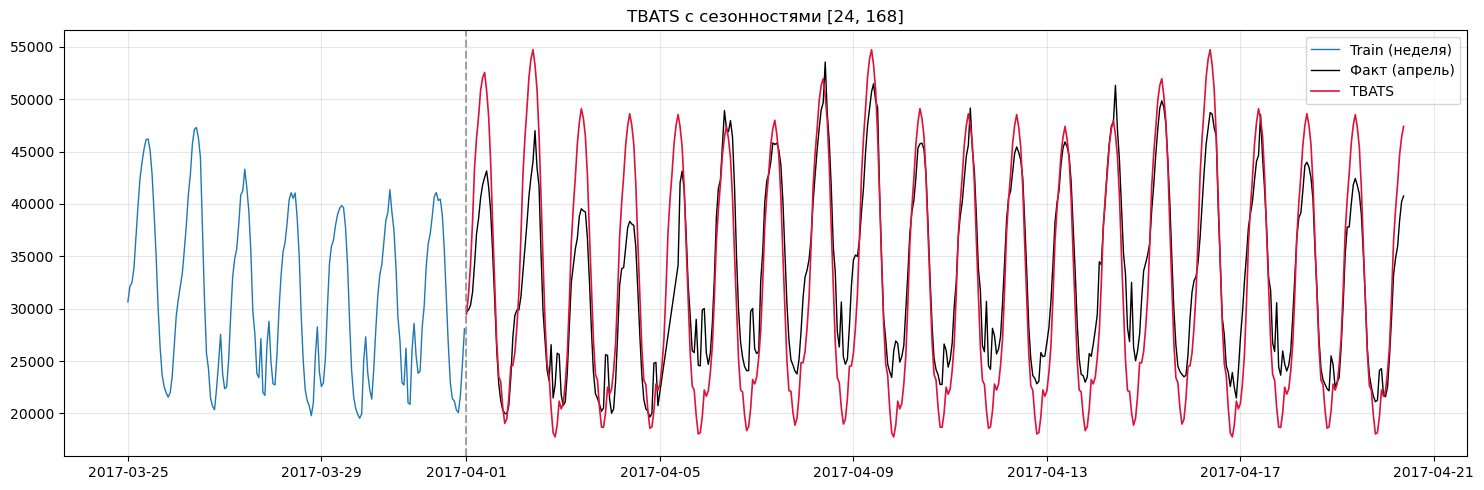

In [22]:
from tbats import TBATS

estimator = TBATS(
    seasonal_periods=[24, 168],
    use_box_cox=False,      # ускоряем подбор
    use_arma_errors=True,
    n_jobs=1,               # безопаснее на Windows
)

tbats_model = estimator.fit(train.values)  # tbats принимает numpy array
print(tbats_model.summary())

# Прогноз
tbats_pred = tbats_model.forecast(steps=len(test))
tbats_pred = pd.Series(tbats_pred, index=test.index)

# Метрики
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{name:<38} MAE={mae:>7,.0f}  RMSE={rmse:>7,.0f}  MAPE={mape:>6.2f}%')
    return dict(MAE=mae, RMSE=rmse, MAPE=mape)

results = {}
results['TBATS [24,168]'] = evaluate('TBATS [24,168]', test, tbats_pred)

# График
plt.figure(figsize=(15, 5))
plt.plot(train.index[-168:], train.iloc[-168:], label='Train (неделя)', linewidth=1)
plt.plot(test.index, test, label='Факт (апрель)', color='black', linewidth=1)
plt.plot(tbats_pred.index, tbats_pred, label='TBATS', color='crimson', linewidth=1.2)
plt.axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--', alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('TBATS с сезонностями [24, 168]')
plt.tight_layout(); plt.show()

Prophet

16:52:08 - cmdstanpy - INFO - Chain [1] start processing
16:52:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet (daily+weekly)                 MAE=  7,248  RMSE=  8,176  MAPE= 24.30%


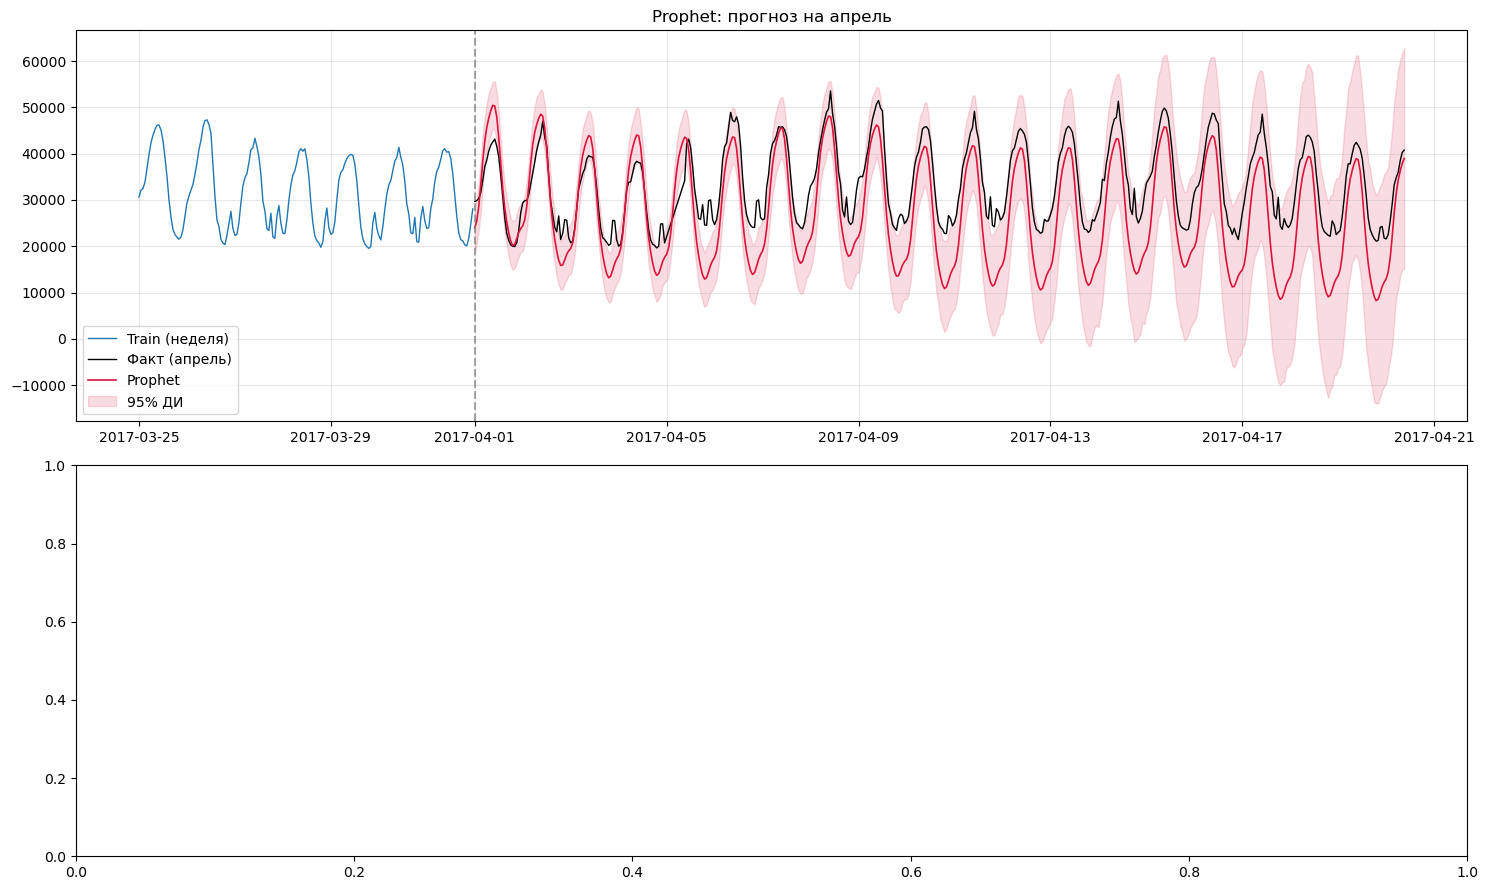

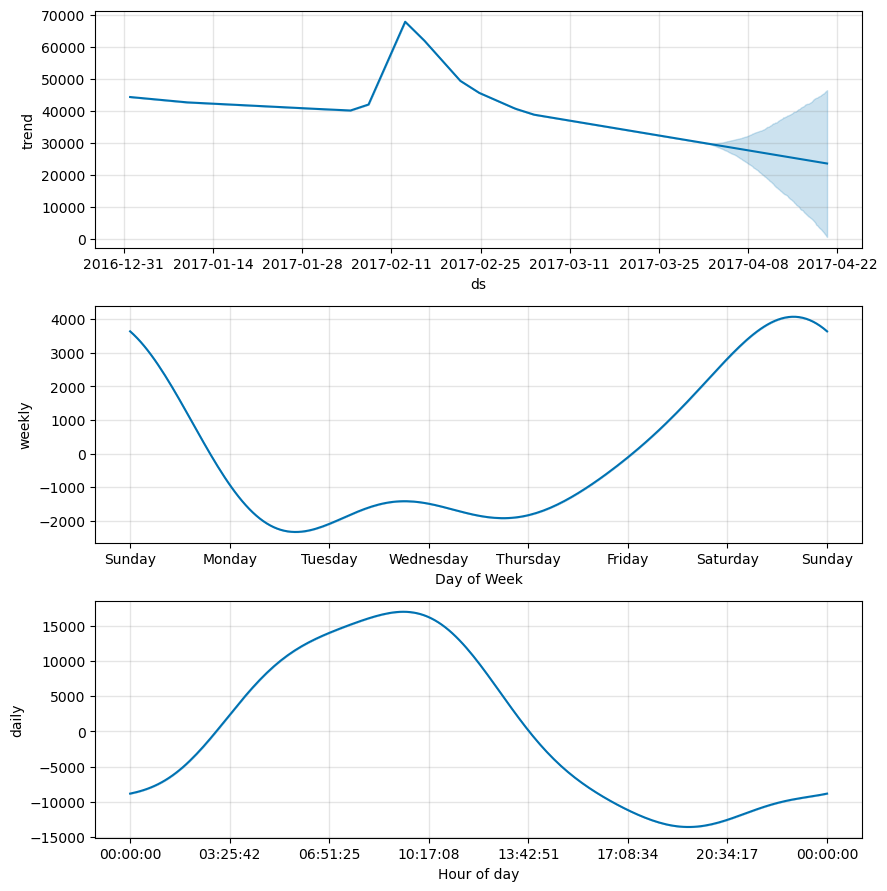

In [23]:
from prophet import Prophet

# Prophet требует свой формат: ds / y
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y': train.values
})

# Для часовых данных — daily seasonality включается автоматически
# weekly_seasonality=True по умолчанию
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,   # у нас только 3.5 месяца — годовой сезонности не хватит данных
    seasonality_mode='additive',
)

m.fit(prophet_train)

# Прогноз: ровно len(test) часов
future = m.make_future_dataframe(periods=len(test), freq='h')
forecast = m.predict(future)

# Достаём только тестовый период
prophet_pred = forecast.set_index('ds')['yhat'].loc[test.index]
prophet_pred_lower = forecast.set_index('ds')['yhat_lower'].loc[test.index]
prophet_pred_upper = forecast.set_index('ds')['yhat_upper'].loc[test.index]

results['Prophet'] = evaluate('Prophet (daily+weekly)', test, prophet_pred)

# Графики
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Прогноз vs факт
axes[0].plot(train.index[-168:], train.iloc[-168:], label='Train (неделя)', linewidth=1)
axes[0].plot(test.index, test, label='Факт (апрель)', color='black', linewidth=1)
axes[0].plot(prophet_pred.index, prophet_pred, label='Prophet', color='crimson', linewidth=1.2)
axes[0].fill_between(prophet_pred.index, prophet_pred_lower, prophet_pred_upper,
                     color='crimson', alpha=0.15, label='95% ДИ')
axes[0].axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--', alpha=0.7)
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Prophet: прогноз на апрель')

# Компоненты
m.plot_components(forecast, ax=axes[1]) if False else None  # plot_components рисует свой figure
plt.tight_layout(); plt.show()

# Отдельно — компоненты
fig_comp = m.plot_components(forecast)
plt.show()

STL + ARIMA

                    STL Decomposition and SARIMAX Results                     
Dep. Variable:                      y   No. Observations:                 2160
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -19323.515
Date:                Mon, 05 Oct 2026   AIC                          38659.030
Time:                        16:55:16   BIC                          38693.095
Sample:                    01-01-2017   HQIC                         38671.490
                         - 03-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -3.9572     19.614     -0.202      0.840     -42.399      34.485
ar.L1          1.1911      0.134      8.915      0.000       0.929       1.453
ar.L2         -0.3619      0.113     -3.201      0.0

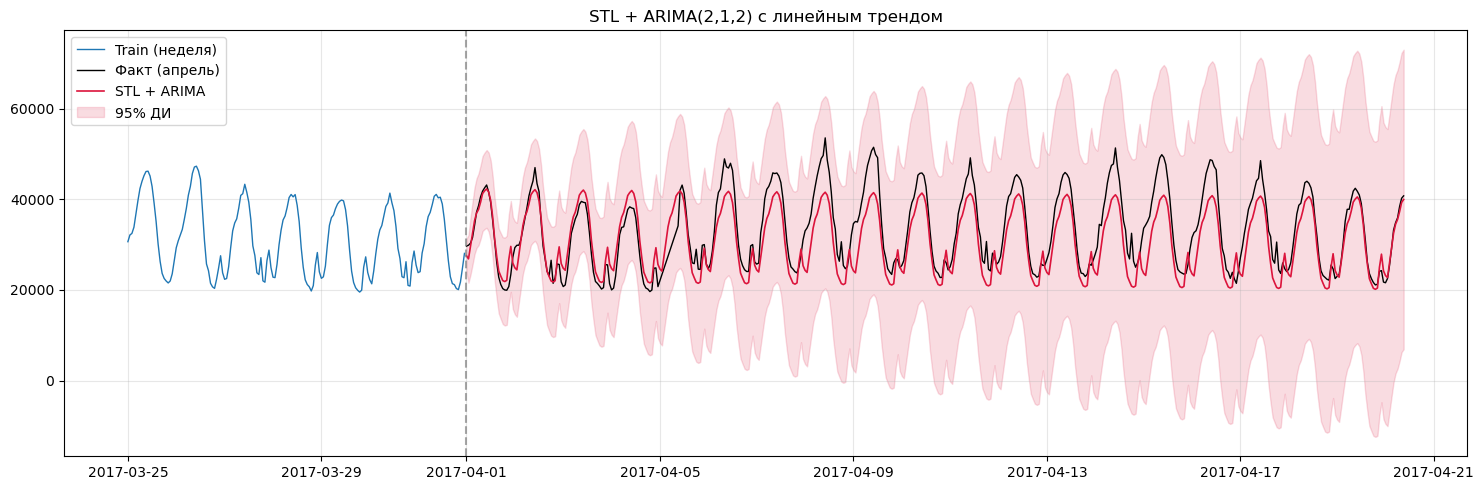

In [25]:
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.arima.model import ARIMA

# STLForecast: STL + ARIMA на десезоннализированном ряде
stlf = STLForecast(
    train,
    ARIMA,
    model_kwargs=dict(order=(2, 1, 2), trend='t'),  # наш лучший порядок + линейный тренд
    period=24,          # суточная сезонность
    seasonal=25,        # длина сезонного сглаживателя (нечётное, >= 7)
    robust=True,        # устойчивость к выбросам
)

stlf_res = stlf.fit()
print(stlf_res.summary())

# Прогноз
stl_pred = stlf_res.forecast(steps=len(test))
stl_pred = pd.Series(stl_pred.values, index=test.index)

# Доверительные интервалы через get_prediction()
# start = len(train) — первый индекс за пределами обучающей выборки
pred_res = stlf_res.get_prediction(start=len(train), end=len(train) + len(test) - 1)
stl_ci = pred_res.conf_int()  # DataFrame с колонками lower / upper
# или pred_res.summary_frame(alpha=0.05) для полной таблицы

# Метрики
results['STL + ARIMA'] = evaluate('STL + ARIMA (2,1,2)+trend', test, stl_pred)

# График
plt.figure(figsize=(15, 5))
plt.plot(train.index[-168:], train.iloc[-168:], label='Train (неделя)', linewidth=1)
plt.plot(test.index, test, label='Факт (апрель)', color='black', linewidth=1)
plt.plot(stl_pred.index, stl_pred, label='STL + ARIMA', color='crimson', linewidth=1.2)
plt.fill_between(stl_ci.index, stl_ci.iloc[:, 0], stl_ci.iloc[:, 1],
                 color='crimson', alpha=0.15, label='95% ДИ')
plt.axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--', alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('STL + ARIMA(2,1,2) с линейным трендом')
plt.tight_layout(); plt.show()

In [26]:
results_df = pd.DataFrame(results).T
results_df['MAE'] = results_df['MAE'].round(0)
results_df['RMSE'] = results_df['RMSE'].round(0)
results_df['MAPE'] = results_df['MAPE'].round(2)

# Добавим лучшие результаты из предыдущих шагов
results_df.loc['SARIMAX (2,1,2)+trend'] = [3658, 4370, 10.99]
results_df.loc['SARIMAX baseline (1,1,1)'] = [3701, 4412, 11.13]
results_df.loc['Grid-best (2,1,2)'] = [3738, 4451, 11.24]

print(results_df.sort_values('MAPE'))

                             MAE    RMSE   MAPE
SARIMAX (2,1,2)+trend     3658.0  4370.0  10.99
STL + ARIMA               3759.0  4514.0  11.13
SARIMAX baseline (1,1,1)  3701.0  4412.0  11.13
Grid-best (2,1,2)         3738.0  4451.0  11.24
TBATS [24,168]            3682.0  4607.0  11.68
Prophet                   7248.0  8176.0  24.30


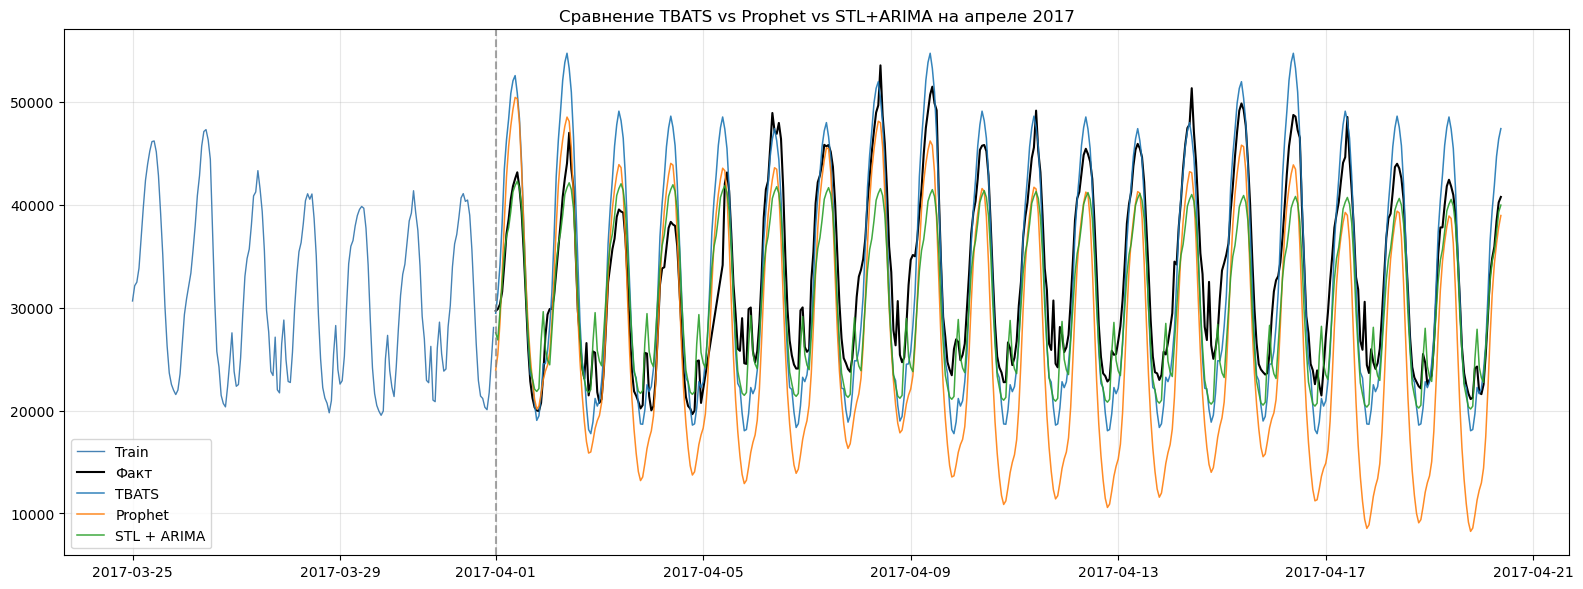

In [27]:
plt.figure(figsize=(16, 6))
plt.plot(train.index[-168:], train.iloc[-168:], label='Train', color='steelblue', linewidth=1)
plt.plot(test.index, test, label='Факт', color='black', linewidth=1.5)

plt.plot(tbats_pred.index, tbats_pred, label='TBATS', linewidth=1.1, alpha=0.9)
plt.plot(prophet_pred.index, prophet_pred, label='Prophet', linewidth=1.1, alpha=0.9)
plt.plot(stl_pred.index, stl_pred, label='STL + ARIMA', linewidth=1.1, alpha=0.9)

plt.axvline(pd.Timestamp('2017-04-01'), color='gray', linestyle='--', alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Сравнение TBATS vs Prophet vs STL+ARIMA на апреле 2017')
plt.tight_layout(); plt.show()